In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

base = Path('.')
Phi = np.load(base / 'Phi.npy')
X_2 = np.load(base / 'x_50k.npy')
y_2 = np.load(base / 'y_50k.npy')

In [2]:
#we need to loop through iq pairs in x_2
#x_2 is formatted as [I0, Q0, I1, Q1, I2, Q2, ...]
ADC = []
for i in range(X_2.shape[0]):
    I = X_2[i, 0::2]
    Q = X_2[i, 1::2]

    phi = Phi[i]

    adc = I*np.cos(phi) - Q*np.sin(phi)
    ADC.append(adc)

ADC = np.array(ADC)

In [ ]:
# pad the data to account for the 8x decimation factor
# insert 8 redundant samples between each original sample

# ADC_padded = np.empty((ADC.shape[0], ADC.shape[1] * 8), dtype=ADC.dtype)

# for i in range(ADC.shape[0]):
#     adc = ADC[i]
#     ADC_padded[i] = np.repeat(adc, 8)

# # print the first 80 samples of the first shot
# print(ADC_padded[0, 0:80])

#np.save("adc_recovered_50k.npy", ADC_padded)

[385.89517748 385.89517748 385.89517748 385.89517748 385.89517748
 385.89517748 385.89517748 385.89517748 381.5965716  381.5965716
 381.5965716  381.5965716  381.5965716  381.5965716  381.5965716
 381.5965716  377.34739511 377.34739511 377.34739511 377.34739511
 377.34739511 377.34739511 377.34739511 377.34739511 373.14731144
 373.14731144 373.14731144 373.14731144 373.14731144 373.14731144
 373.14731144 373.14731144 368.99598318 368.99598318 368.99598318
 368.99598318 368.99598318 368.99598318 368.99598318 368.99598318
 364.89307216 364.89307216 364.89307216 364.89307216 364.89307216
 364.89307216 364.89307216 364.89307216 360.83823949 360.83823949
 360.83823949 360.83823949 360.83823949 360.83823949 360.83823949
 360.83823949 356.83114568 356.83114568 356.83114568 356.83114568
 356.83114568 356.83114568 356.83114568 356.83114568 352.87145066
 352.87145066 352.87145066 352.87145066 352.87145066 352.87145066
 352.87145066 352.87145066 348.95881385 348.95881385 348.95881385
 348.9588138

Text(0.5, 0, 'Sample Index')

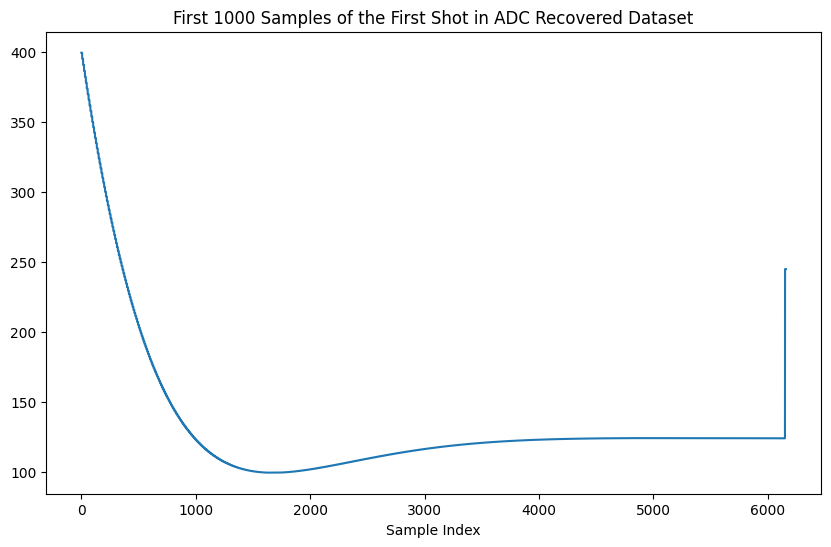

In [4]:
#visualize the adc_recovered dataset
plt.figure(figsize=(10, 6))
# Plot the first 1000 samples of the first shot
plt.plot(ADC_padded[403, 0:10000])
plt.title("First 1000 Samples of the First Shot in ADC Recovered Dataset")
plt.xlabel("Sample Index")


In [5]:
shot = ADC_padded[0]

print("dtype:", shot.dtype)
print("length:", len(shot))
print("min:", shot.min())
print("max:", shot.max())

dtype: float64
length: 6160
min: 112.61761579066169
max: 735.9066087808854


In [6]:
waveform = ADC_padded[0]
# remove DC offset
waveform = waveform - np.mean(waveform)
# normalize amplitude
waveform = waveform / np.max(np.abs(waveform))

print(waveform.min(), waveform.max())
np.save("dac_waveform_shot0.npy", waveform)

-0.06068702743444902 1.0


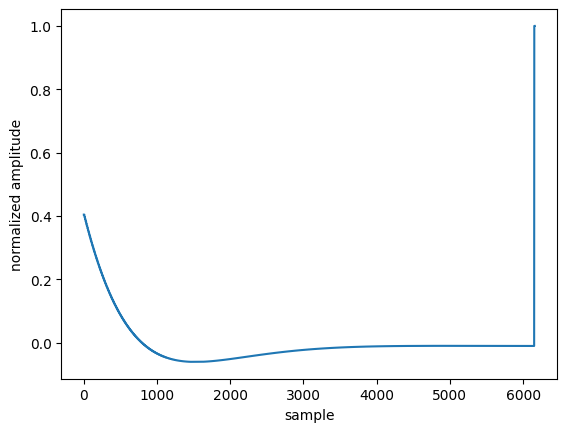

In [7]:
plt.plot(waveform)
plt.xlabel("sample")
plt.ylabel("normalized amplitude")
plt.show()

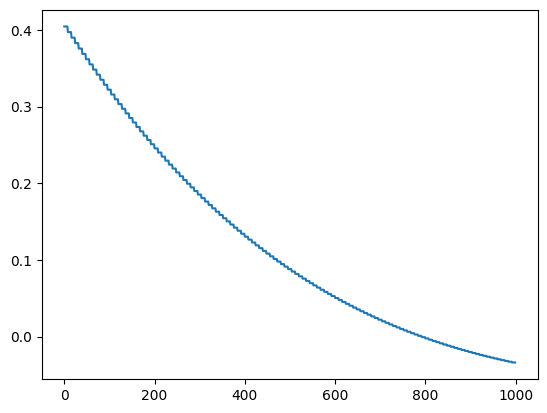

In [8]:
plt.plot(waveform[:1000])
plt.show()

In [11]:
#truncate dataset to 1k samples
ADC_truncated = ADC[:1000]
#truncate the y dataset to 1k samples
y_truncated = y_2[:1000]

#save
np.save("adc_recovered_1k_truncated.npy", ADC_truncated)
np.save("y_1k_truncated.npy", y_truncated)